 01 — Exploração inicial: licitações federais (jan/2024)

**Fonte:** Portal da Transparência — 2.537 licitações, 17 colunas.

## Achados
- Distribuição de valores com forte cauda longa: mediana R$ 6 mil vs média R$ 872 mil → média e desvio-padrão são referências ruins; usar quantis.
- ~25% das licitações com valor R$ 0 (não concluídas) — excluir das análises de valor.
- 477 dispensas de licitação (19% do total). 31 acima do teto legal de ~R$ 62 mil — top 10 analisado: maioria com amparo legal aparente (remanescente de contrato, emergência, sigilo, PAA).
- Hipótese em aberto: concentração de valores logo abaixo do teto de dispensa (structuring) — investigação na fase 1.

In [1]:
import sys
sys.executable

'c:\\auditoria-ml\\.venv\\Scripts\\python.exe'

In [3]:
%pip install pandas numpy matplotlib requests

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.1-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached charset_normalizer-3.4.9-cp313-cp313-win_amd64.whl.metadata (42 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cac

In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/202401_Licitação.csv",
    sep=";",
    encoding="latin-1",
    decimal=","
)

df.shape


(2537, 17)

In [2]:
df.shape


(2537, 17)

In [3]:
df.head()

,Número Licitação,Código UG,Nome UG,Código Modalidade Compra,Modalidade Compra,Número Processo,Objeto,Situação Licitação,Código Órgão Superior,Nome Órgão Superior,Código Órgão,Nome Órgão,UF,Município,Data Resultado Compra,Data Abertura,Valor Licitação
0,12023,130094,SUPERINT.DE AGRICULTURA E PECUARIA - SFA/PA,5,Pregão,21030.002858/2023,Objeto: Pregão Eletrônico - Contratação de emp...,Evento de Adiamento Publicado,22000,Ministério da Agricultura e Pecuária,22000,Ministério da Agricultura e Pecuária - Unid,PA,BELEM,17/01/2024,26/12/2023,170612.00
1,12023,135008,EMBRAPA/CPAF-AP,7,Inexigibilidade de Licitação,21157001423202338,Objeto: Aquisição de serviço para atualização ...,Encerrado,22000,Ministério da Agricultura e Pecuária,22202,Empresa Brasileira de Pesquisa Agropecuária,AP,MACAPA,08/01/2024,NaN,26636.45
2,12023,135020,EMBRAPA/CTAA,7,Inexigibilidade de Licitação,21152.001449/2023,Objeto: Aquisição de Insumos para Utilização n...,Publicado,22000,Ministério da Agricultura e Pecuária,22202,Empresa Brasileira de Pesquisa Agropecuária,RJ,RIO DE JANEIRO,02/01/2024,NaN,100061.60
3,12023,135039,EMBRAPA/CPAC,7,Inexigibilidade de Licitação,21167.001652/2023,Objeto: Aquisição de Selo GFP para Equipamento...,Encerrado,22000,Ministério da Agricultura e Pecuária,22202,Empresa Brasileira de Pesquisa Agropecuária,DF,BRASILIA,08/01/2024,NaN,3097.50
4,12023,152237,CAMPUS ARRAIAL DO CABO,9999,Pregão - Registro de Preço,23826000189202327,Objeto: Pregão Eletrônico - Contratação de emp...,Publicado,26000,Ministério da Educação,26433,"Instituto Federal de Educação, Ciência e T",RJ,ARRAIAL DO CABO,18/01/2024,08/01/2024,11890.00


In [4]:
df.columns.tolist()

['Número Licitação',
 'Código UG',
 'Nome UG',
 'Código Modalidade Compra',
 'Modalidade Compra',
 'Número Processo',
 'Objeto',
 'Situação Licitação',
 'Código Órgão Superior',
 'Nome Órgão Superior',
 'Código Órgão',
 'Nome Órgão',
 'UF',
 'Município',
 'Data Resultado Compra',
 'Data Abertura',
 'Valor Licitação']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Número Licitação          2537 non-null   int64  
 1   Código UG                 2537 non-null   int64  
 2   Nome UG                   2537 non-null   str    
 3   Código Modalidade Compra  2537 non-null   int64  
 4   Modalidade Compra         2537 non-null   str    
 5   Número Processo           2537 non-null   str    
 6   Objeto                    2537 non-null   str    
 7   Situação Licitação        2537 non-null   str    
 8   Código Órgão Superior     2537 non-null   int64  
 9   Nome Órgão Superior       2537 non-null   str    
 10  Código Órgão              2537 non-null   int64  
 11  Nome Órgão                2537 non-null   str    
 12  UF                        2537 non-null   str    
 13  Município                 2537 non-null   str    
 14  Data Resultado Comp

In [6]:
df["Modalidade Compra"].value_counts()

Modalidade Compra
Pregão - Registro de Preço      1207
Pregão                           744
Dispensa de Licitação            477
Inexigibilidade de Licitação      58
Concorrência                      27
Tomada de Preços                  24
Name: count, dtype: int64

In [7]:
df["Valor Licitação"].describe()

count    2.537000e+03
mean     8.725829e+05
std      4.715575e+06
min      0.000000e+00
25%      0.000000e+00
50%      6.083350e+03
75%      1.319996e+05
max      9.037715e+07
Name: Valor Licitação, dtype: float64

In [8]:
df[df["Modalidade Compra"] == "Dispensa de Licitação"]["Valor Licitação"].describe()

count    4.770000e+02
mean     4.210225e+04
std      2.009452e+05
min      0.000000e+00
25%      1.594000e+03
50%      5.934000e+03
75%      1.690000e+04
max      2.431039e+06
Name: Valor Licitação, dtype: float64

In [9]:
dispensas = df[df["Modalidade Compra"] == "Dispensa de Licitação"]
acima_teto = dispensas[dispensas["Valor Licitação"] > 62000]
len(acima_teto)

31

In [10]:
acima_teto.sort_values("Valor Licitação", ascending=False)[
    ["Nome UG", "Nome Órgão Superior", "Municipio" if "Municipio" in acima_teto.columns else "Município", "Objeto", "Valor Licitação"]
].head(10)

,Nome UG,Nome Órgão Superior,Município,Objeto,Valor Licitação
664,FUNDACAO NACIONAL DOS POVOS INDIGENAS,Ministério dos Povos Indígenas,BRASILIA,Objeto: Prestação dos serviços de vigilância p...,2431038.84
2451,HOSPITAL UNIVERSITARIO PROF. EDGARD SANTOS,Ministério da Educação,SALVADOR,Objeto: Serviços continuados de Lavanderia Hos...,1887000.00
2323,UNIVERSIDADE FEDERAL DA BAHIA,Ministério da Educação,SALVADOR,Objeto: Contratação de empresa remanescente do...,1758023.04
2361,IBAMA - SUPERINTENDENCIA DE SAO PAULO/SP,Ministério do Meio Ambiente e Mudança do Cl,SAO PAULO,Objeto: Contratação de remanescente de serviço...,1668514.32
2346,BASE ADMINISTRATIVA DA GUARNICAO DE JP,Ministério da Defesa,JOAO PESSOA,Objeto: Aquisição de alimentos de agricultores...,1232141.17
2442,INDUSTRIA DE MATERIAL BELICO DO BRASIL/FE,Ministério da Defesa,MAGE,Objeto: Serviço de fornecimento de energia elé...,1000000.00
2372,COORDENACAO GERAL DE ADMINISTRACAO CGAD/DLOG/,Ministério da Justiça e Segurança Pública,BRASILIA,Informação protegida por sigilo nos termos da ...,636951.12
2320,EMBRAPA/CPAMN,Ministério da Agricultura e Pecuária,TERESINA,"Objeto: Prestação, de natureza continuada, com...",599192.27
2493,HOSPITAL UNIVERSITARIO ANTONIO PEDRO,Ministério da Educação,NITEROI,Objeto: Contratação fornecimento de energia el...,592438.16
677,COMPANHIA DOCAS DO RIO DE JANEIRO,Ministério dos Transportes,RIO DE JANEIRO,Objeto: Prestação dos serviços de limpeza e co...,545374.77


In [11]:
acima_teto.sort_values("Valor Licitação", ascending=False)[
    ["Nome UG", "Nome Órgão Superior", "Município", "Objeto", "Valor Licitação"]
].head(10)

,Nome UG,Nome Órgão Superior,Município,Objeto,Valor Licitação
664,FUNDACAO NACIONAL DOS POVOS INDIGENAS,Ministério dos Povos Indígenas,BRASILIA,Objeto: Prestação dos serviços de vigilância p...,2431038.84
2451,HOSPITAL UNIVERSITARIO PROF. EDGARD SANTOS,Ministério da Educação,SALVADOR,Objeto: Serviços continuados de Lavanderia Hos...,1887000.00
2323,UNIVERSIDADE FEDERAL DA BAHIA,Ministério da Educação,SALVADOR,Objeto: Contratação de empresa remanescente do...,1758023.04
2361,IBAMA - SUPERINTENDENCIA DE SAO PAULO/SP,Ministério do Meio Ambiente e Mudança do Cl,SAO PAULO,Objeto: Contratação de remanescente de serviço...,1668514.32
2346,BASE ADMINISTRATIVA DA GUARNICAO DE JP,Ministério da Defesa,JOAO PESSOA,Objeto: Aquisição de alimentos de agricultores...,1232141.17
2442,INDUSTRIA DE MATERIAL BELICO DO BRASIL/FE,Ministério da Defesa,MAGE,Objeto: Serviço de fornecimento de energia elé...,1000000.00
2372,COORDENACAO GERAL DE ADMINISTRACAO CGAD/DLOG/,Ministério da Justiça e Segurança Pública,BRASILIA,Informação protegida por sigilo nos termos da ...,636951.12
2320,EMBRAPA/CPAMN,Ministério da Agricultura e Pecuária,TERESINA,"Objeto: Prestação, de natureza continuada, com...",599192.27
2493,HOSPITAL UNIVERSITARIO ANTONIO PEDRO,Ministério da Educação,NITEROI,Objeto: Contratação fornecimento de energia el...,592438.16
677,COMPANHIA DOCAS DO RIO DE JANEIRO,Ministério dos Transportes,RIO DE JANEIRO,Objeto: Prestação dos serviços de limpeza e co...,545374.77


In [12]:
len(acima_teto)

31

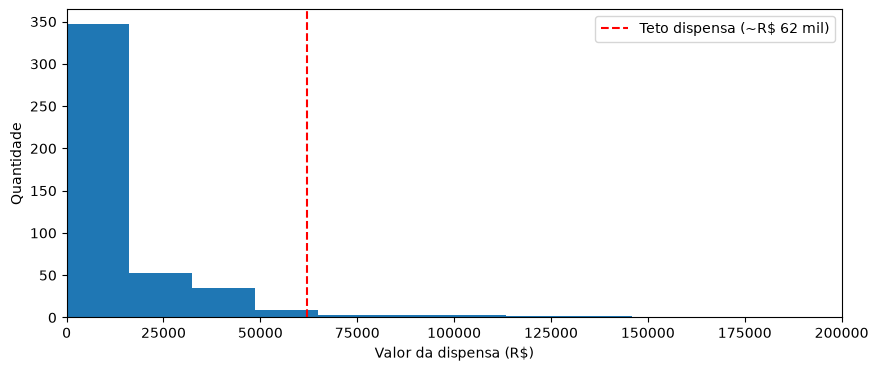

In [15]:
import matplotlib.pyplot as plt

valores = dispensas[dispensas["Valor Licitação"] > 0]["Valor Licitação"]

plt.figure(figsize=(10, 4))
plt.hist(valores, bins=150)
plt.axvline(62000, color="red", linestyle="--", label="Teto dispensa (~R$ 62 mil)")
plt.xlim(0, 200000)
plt.xlabel("Valor da dispensa (R$)")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

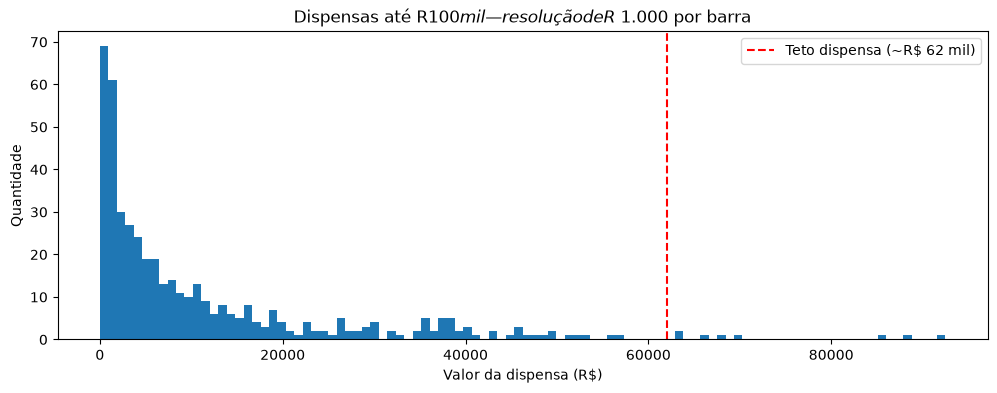

In [16]:
valores_zoom = valores[valores <= 100000]

plt.figure(figsize=(12, 4))
plt.hist(valores_zoom, bins=100)
plt.axvline(62000, color="red", linestyle="--", label="Teto dispensa (~R$ 62 mil)")
plt.xlabel("Valor da dispensa (R$)")
plt.ylabel("Quantidade")
plt.title("Dispensas até R$ 100 mil — resolução de R$ 1.000 por barra")
plt.legend()
plt.show()